Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base directory: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification
Case: neel_dw
Loading from: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/neel_dw/20260505_06
Saving results to: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/calibration/neel_dw/20260505_02

M_predicted shape: (255, 255)
M_std shape:       (255, 255)
M_true shape:      (255, 255)
M_predicted range: -3.0219 ~ 2.7064
M_std range:       0.000029 ~ 0.013541
M_true range:      -5.3766 ~ 5.3766
=== Diagnostics ===
M_predicted std across image: 1.875134
M_true std across image:      5.355244
M_std mean:                   0.003905
M_std / M_predicted.std():    0.0021
M_predicted range:            -3.0219 ~ 2.7064
M_std range:                  0.000029 ~ 0.013541
M_true range:                 -5.3766 ~ 5.3766

M_std min:  0.00002945
sigm

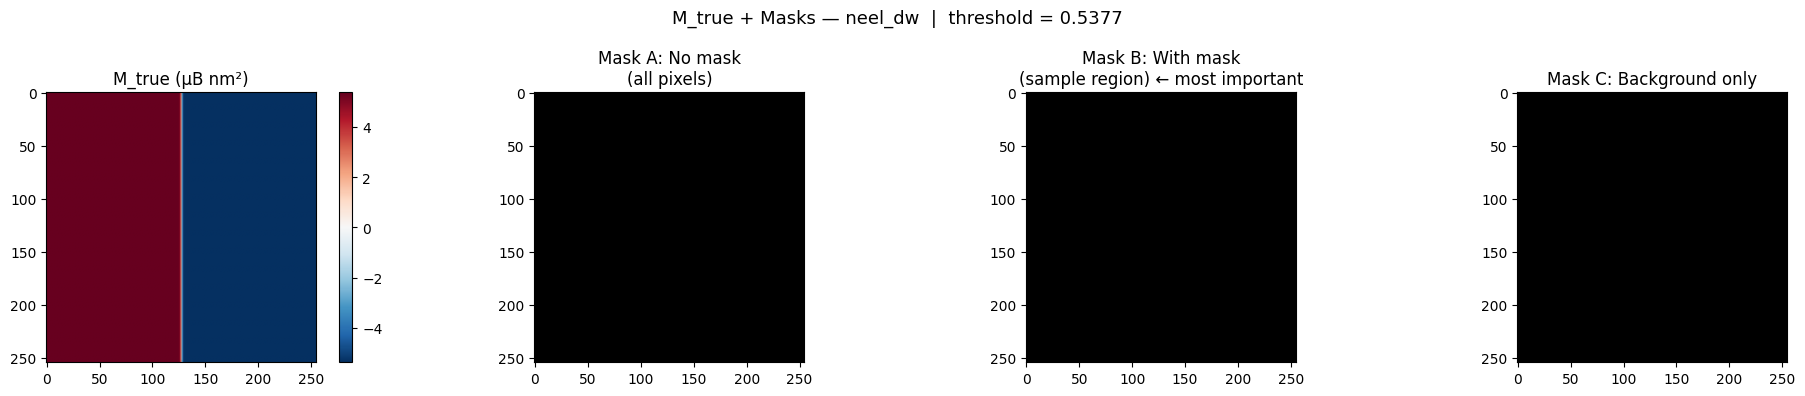

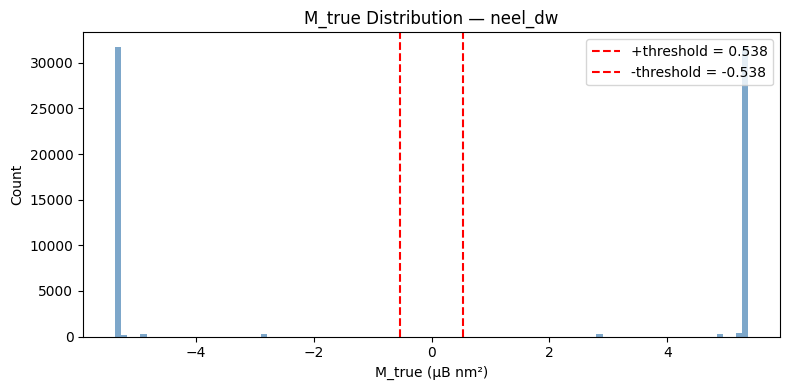

z-score range: -158201.466 ~ 176425.628
z-score mean:  -30.524
z-score std:   5774.492

Mask A (No mask):
  Pixels:  65025
  z mean:  -30.524
  z std:   5774.492
  |z| ≤ 1: 0.000  (ideal: 0.683)
  |z| ≤ 2: 0.000  (ideal: 0.954)
  |z| ≤ 3: 0.000  (ideal: 0.997)

Mask B (With mask):
  Pixels:  65025
  z mean:  -30.524
  z std:   5774.492
  |z| ≤ 1: 0.000  (ideal: 0.683)
  |z| ≤ 2: 0.000  (ideal: 0.954)
  |z| ≤ 3: 0.000  (ideal: 0.997)

Mask C (Background): No pixels, skipping



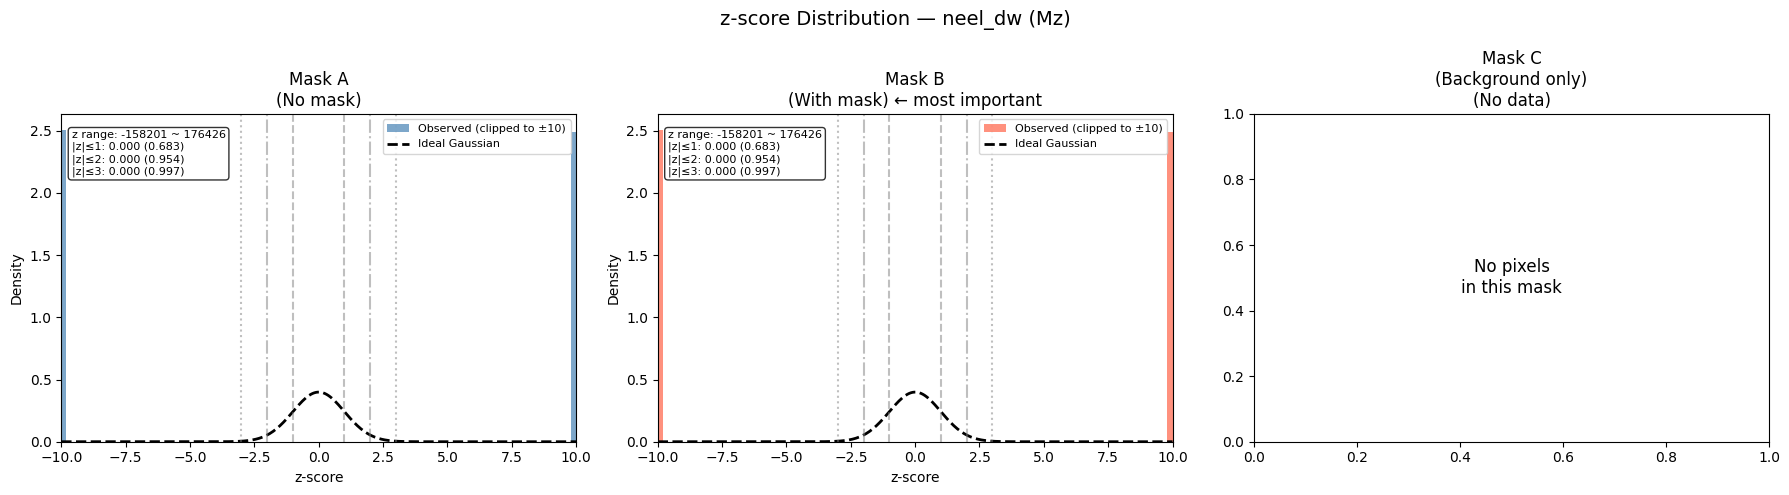


Mask A (No mask):
  ECE = 3.624772
  Group  1: σ=0.00060  ε=4.73016  n=6503
  Group  2: σ=0.00152  ε=4.07214  n=6503
  Group  3: σ=0.00214  ε=3.76452  n=6503
  Group  4: σ=0.00265  ε=3.56586  n=6503
  Group  5: σ=0.00321  ε=3.54553  n=6503
  Group  6: σ=0.00403  ε=3.46630  n=6502
  Group  7: σ=0.00502  ε=3.43935  n=6502
  Group  8: σ=0.00584  ε=3.33235  n=6502
  Group  9: σ=0.00653  ε=3.18647  n=6502
  Group 10: σ=0.00751  ε=3.18385  n=6502

Mask B (With mask) ← most important:
  ECE = 3.624772
  Group  1: σ=0.00060  ε=4.73016  n=6503
  Group  2: σ=0.00152  ε=4.07214  n=6503
  Group  3: σ=0.00214  ε=3.76452  n=6503
  Group  4: σ=0.00265  ε=3.56586  n=6503
  Group  5: σ=0.00321  ε=3.54553  n=6503
  Group  6: σ=0.00403  ε=3.46630  n=6502
  Group  7: σ=0.00502  ε=3.43935  n=6502
  Group  8: σ=0.00584  ε=3.33235  n=6502
  Group  9: σ=0.00653  ε=3.18647  n=6502
  Group 10: σ=0.00751  ε=3.18385  n=6502


/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11326/711368061.py:397: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAP

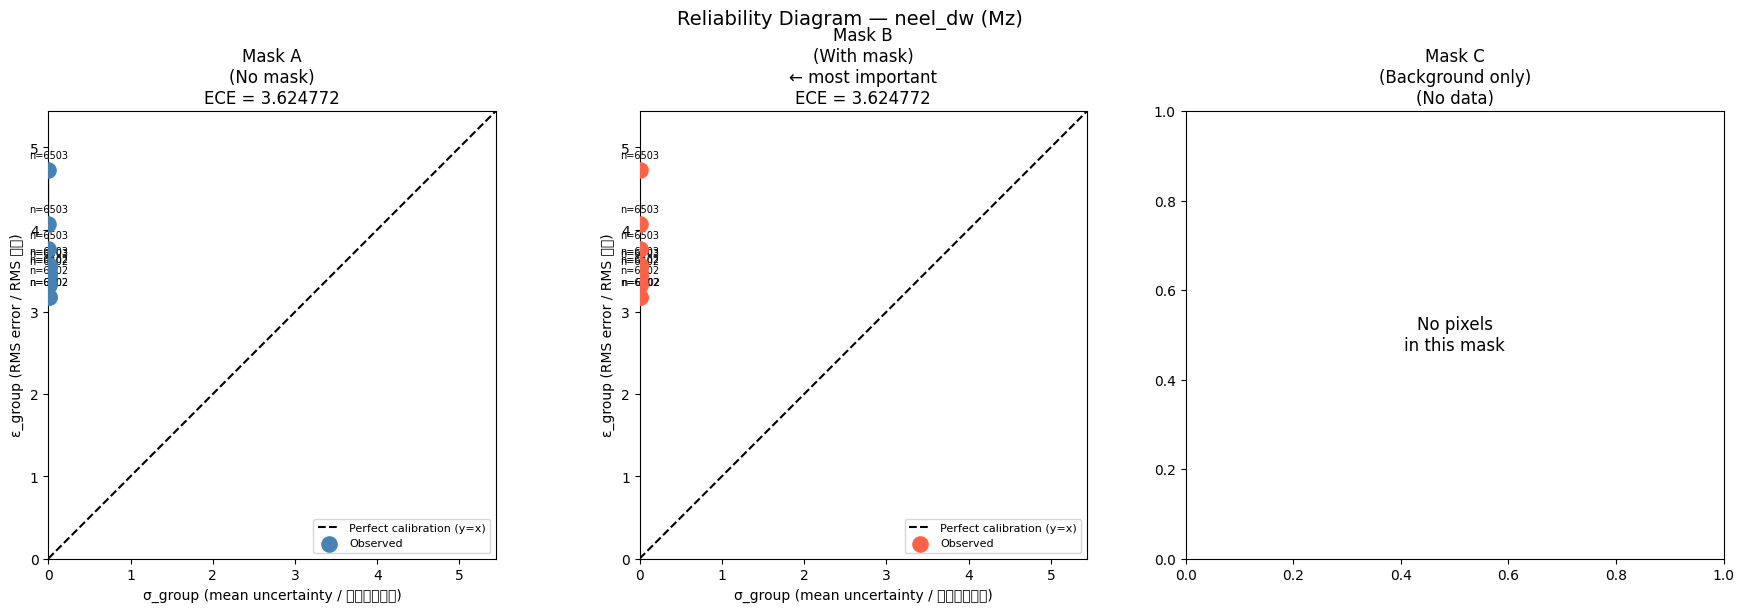

Calibration report saved to:
  /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/calibration/neel_dw/20260505_02/calibration_report.txt

All results saved to:
  /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/calibration/neel_dw/20260505_02


In [9]:
# ============================================================
# Calibration Analysis — MC Dropout Uncertainty Quantification
# 校准分析 — MC Dropout 不确定性量化
# Author / 作者: Yue Yu, TU Dresden / ct.qmat


# ======================================================
# Cell 1: 挂载云端硬盘 + 导入库
# Mount Google Drive + Import Libraries
# ======================================================
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime

# 项目根目录 / Project root directory
BASE = '/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification'
print("Base directory:", BASE)

# ======================================================
# Cell 2: 选择 case + 加载数据 + 创建日期输出目录
# Select Case + Load Data + Create Dated Output Directory
# ======================================================
CASE = "neel_dw"   # ← 只改这里切换 case / Change here to switch case
                   #   可选 / Options: "neel_dw" 或 "skyrmion"

# 自动读取最新重建结果 / Auto-load latest reconstruction results
result_base = os.path.join(BASE, 'uberesult', CASE)
all_dirs = sorted([d for d in glob.glob(os.path.join(result_base, '*'))
                   if os.path.isdir(d)])
latest_dir = all_dirs[-1]
print(f"Case: {CASE}")
print(f"Loading from: {latest_dir}")

# 加载重建结果和真值 / Load reconstruction results and ground truth
M_predicted = np.load(os.path.join(latest_dir, 'M_predicted.npy'))
M_std       = np.load(os.path.join(latest_dir, 'M_std.npy'))
M_true      = np.load(os.path.join(latest_dir, 'M_true_converted.npy'))

# 对齐数组尺寸（M_true 可能比 M_predicted 大一个像素）
# Align array shapes (M_true may be 1 pixel larger than M_predicted)
M_true = M_true[:M_predicted.shape[0], :M_predicted.shape[1]]

# 创建日期序号输出目录，避免覆盖历史结果
# Create dated output directory to avoid overwriting previous results
calib_base = os.path.join(BASE, 'calibration', CASE)
os.makedirs(calib_base, exist_ok=True)

date_str = datetime.now().strftime("%Y%m%d")
idx = 1
while os.path.exists(os.path.join(calib_base, f"{date_str}_{idx:02d}")):
    idx += 1
calib_dir = os.path.join(calib_base, f"{date_str}_{idx:02d}")
os.makedirs(calib_dir, exist_ok=True)

print(f"Saving results to: {calib_dir}")
print(f"\nM_predicted shape: {M_predicted.shape}")
print(f"M_std shape:       {M_std.shape}")
print(f"M_true shape:      {M_true.shape}")
print(f"M_predicted range: {M_predicted.min():.4f} ~ {M_predicted.max():.4f}")
print(f"M_std range:       {M_std.min():.6f} ~ {M_std.max():.6f}")
print(f"M_true range:      {M_true.min():.4f} ~ {M_true.max():.4f}")

# ======================================================
# Cell 3: 诊断 + Sigma Floor
# Diagnostics + Sigma Floor
# ======================================================
# 诊断输出：检查 M_std 和 M_predicted 的量级关系
# Diagnostic: Check relative magnitude of M_std vs M_predicted
print("=== Diagnostics ===")
print(f"M_predicted std across image: {M_predicted.std():.6f}")
print(f"M_true std across image:      {M_true.std():.6f}")
print(f"M_std mean:                   {M_std.mean():.6f}")
print(f"M_std / M_predicted.std():    {M_std.mean() / M_predicted.std():.4f}")
print(f"M_predicted range:            {M_predicted.min():.4f} ~ {M_predicted.max():.4f}")
print(f"M_std range:                  {M_std.min():.6f} ~ {M_std.max():.6f}")
print(f"M_true range:                 {M_true.min():.4f} ~ {M_true.max():.4f}")
print()

# Sigma Floor：防止 std = 0 导致 z-score 除以零
# Sigma Floor: Prevent z-score division by zero when std = 0
# 参考博后建议 / As suggested by postdoc: σ = max(σ_min, σ*)
sigma_min = M_std.min() / 10   # σ_min 设为最小 std 的 1/10 / Set to 1/10 of minimum std
print(f"M_std min:  {M_std.min():.8f}")
print(f"sigma_min:  {sigma_min:.8f}")

sigma = np.maximum(sigma_min, M_std)

# 记录被 clip 的像素数 / Count pixels clipped by sigma floor
n_clipped = np.sum(M_std < sigma_min)
n_total   = M_std.size
print(f"\nClipped pixels: {n_clipped} / {n_total} "
      f"({100*n_clipped/n_total:.4f}%)")

# ======================================================
# Cell 4: 三种 Mask / Three Masks
# ======================================================
# 用相对阈值区分样品区域和背景区域
# Use relative threshold to separate sample and background regions
threshold = 0.1 * np.max(np.abs(M_true))  # 10% of max|M_true|
print(f"Threshold: {threshold:.4f} "
      f"(10% of max|M_true| = {np.max(np.abs(M_true)):.4f})")

# Mask A: No mask（所有像素 / All pixels）
mask_A = np.ones(M_true.shape, dtype=bool)

# Mask B: With mask（样品区域，最重要 / Sample region, most important）
# 参考博后建议 / As suggested by postdoc: pixels where M_true is non-zero
mask_B = (np.abs(M_true) > threshold)

# Mask C: Background only（背景区域 / Background region）
mask_C = (np.abs(M_true) <= threshold)

print(f"\nMask A (No mask):    {mask_A.sum()} pixels")
print(f"Mask B (With mask):  {mask_B.sum()} pixels  ← most important")
print(f"Mask C (Background): {mask_C.sum()} pixels")
print(f"Total:               {M_true.size} pixels")

# 可视化 M_true 和三种 mask / Visualise M_true and three masks
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

im = axes[0].imshow(M_true, cmap='RdBu_r', origin='upper')
axes[0].set_title('M_true (μB nm²)')
plt.colorbar(im, ax=axes[0])

axes[1].imshow(mask_A, cmap='gray', origin='upper')
axes[1].set_title('Mask A: No mask\n(all pixels)')

axes[2].imshow(mask_B, cmap='gray', origin='upper')
axes[2].set_title('Mask B: With mask\n(sample region) ← most important')

axes[3].imshow(mask_C, cmap='gray', origin='upper')
axes[3].set_title('Mask C: Background only')

plt.suptitle(f'M_true + Masks — {CASE}  |  threshold = {threshold:.4f}',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(calib_dir, '1_masks.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# M_true 值分布直方图，用于检查 threshold 是否合理
# M_true value distribution histogram to verify threshold selection
plt.figure(figsize=(8, 4))
plt.hist(M_true.flatten(), bins=100, color='steelblue', alpha=0.7)
plt.axvline( threshold, color='red', linestyle='--',
             label=f'+threshold = {threshold:.3f}')
plt.axvline(-threshold, color='red', linestyle='--',
             label=f'-threshold = {-threshold:.3f}')
plt.xlabel('M_true (μB nm²)')
plt.ylabel('Count')
plt.title(f'M_true Distribution — {CASE}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(calib_dir, '1b_Mtrue_histogram.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 5: z-score 计算 + 统计
# z-score Calculation + Statistics
# ======================================================
# z-score = (M_predicted - M_true) / sigma
# 参考 Chuan Guo et al. 2017 / Reference: Chuan Guo et al. 2017
z_score = (M_predicted - M_true) / sigma

print(f"z-score range: {z_score.min():.3f} ~ {z_score.max():.3f}")
print(f"z-score mean:  {z_score.mean():.3f}")
print(f"z-score std:   {z_score.std():.3f}")
print()

# 检验高斯校准标准 / Check Gaussian calibration criteria
for mask_name, mask in [('A (No mask)',    mask_A),
                         ('B (With mask)',  mask_B),
                         ('C (Background)', mask_C)]:
    # 跳过没有像素的 mask / Skip empty masks
    if mask.sum() == 0:
        print(f"Mask {mask_name}: No pixels, skipping\n")
        continue

    z = z_score[mask]
    frac_1 = np.mean(np.abs(z) <= 1)
    frac_2 = np.mean(np.abs(z) <= 2)
    frac_3 = np.mean(np.abs(z) <= 3)
    print(f"Mask {mask_name}:")
    print(f"  Pixels:  {mask.sum()}")
    print(f"  z mean:  {z.mean():.3f}")
    print(f"  z std:   {z.std():.3f}")
    print(f"  |z| ≤ 1: {frac_1:.3f}  (ideal: 0.683)")
    print(f"  |z| ≤ 2: {frac_2:.3f}  (ideal: 0.954)")
    print(f"  |z| ≤ 3: {frac_3:.3f}  (ideal: 0.997)")
    print()

# ======================================================
# Cell 6: z-score 分布图
# z-score Distribution Plot
# ======================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mask_list  = [mask_A, mask_B, mask_C]
title_list = ['Mask A\n(No mask)',
              'Mask B\n(With mask) ← most important',
              'Mask C\n(Background only)']
color_list = ['steelblue', 'tomato', 'seagreen']

for ax, mask, title, color in zip(axes, mask_list, title_list, color_list):
    # 跳过空 mask / Skip empty mask
    if mask.sum() == 0:
        ax.text(0.5, 0.5, 'No pixels\nin this mask',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{title}\n(No data)')
        continue

    z = z_score[mask]

    # 将 z-score 裁剪到 ±10 以便可视化（实际范围可能远超此值）
    # Clip z-score to ±10 for visualisation (actual range may exceed this)
    z_clip = np.clip(z, -10, 10)
    ax.hist(z_clip, bins=100, color=color, alpha=0.7,
            density=True, label='Observed (clipped to ±10)')

    # 理想高斯分布（校准良好时 z-score 应服从标准正态分布）
    # Ideal Gaussian (well-calibrated z-scores follow standard normal distribution)
    x = np.linspace(-10, 10, 300)
    ax.plot(x, norm.pdf(x), 'k--', linewidth=2, label='Ideal Gaussian')

    # 标记 ±1σ, ±2σ, ±3σ 参考线 / Mark ±1σ, ±2σ, ±3σ reference lines
    for v, ls in zip([1, 2, 3], ['--', '-.', ':']):
        ax.axvline( v, color='gray', linestyle=ls, alpha=0.5)
        ax.axvline(-v, color='gray', linestyle=ls, alpha=0.5)

    frac_1 = np.mean(np.abs(z) <= 1)
    frac_2 = np.mean(np.abs(z) <= 2)
    frac_3 = np.mean(np.abs(z) <= 3)

    ax.set_title(title)
    ax.set_xlabel('z-score')
    ax.set_ylabel('Density')
    ax.set_xlim(-10, 10)
    ax.legend(fontsize=8)
    ax.text(0.02, 0.95,
            f"z range: {z.min():.0f} ~ {z.max():.0f}\n"
            f"|z|≤1: {frac_1:.3f} (0.683)\n"
            f"|z|≤2: {frac_2:.3f} (0.954)\n"
            f"|z|≤3: {frac_3:.3f} (0.997)",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'z-score Distribution — {CASE} (Mz)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(calib_dir, '2_zscore_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 7: Reliability Diagram + ECE
# 可靠性图 + 期望校准误差
# ======================================================
def compute_reliability(M_pred_flat, M_true_flat, sigma_flat, n_bins=10):
    """
    计算 Reliability Diagram 数据和 ECE
    Compute Reliability Diagram data and ECE

    方法 / Method:
    1. 按 sigma 从小到大排序所有像素
       Sort all pixels by sigma in ascending order
    2. 分成 n_bins 组（deciles）
       Divide into n_bins groups (deciles)
    3. 每组计算 sigma_group 和 epsilon_group
       Compute sigma_group and epsilon_group per group
    4. ECE = Σ (N_b/N) |ε_group - σ_group|
       参考 / Reference: Chuan Guo et al. 2017
    """
    # 按 sigma 排序 / Sort by sigma
    sort_idx     = np.argsort(sigma_flat)
    sigma_sorted = sigma_flat[sort_idx]
    pred_sorted  = M_pred_flat[sort_idx]
    true_sorted  = M_true_flat[sort_idx]

    # 分组 / Group into bins
    bins = np.array_split(np.arange(len(sigma_flat)), n_bins)

    sigma_group = []
    eps_group   = []
    n_group     = []

    for b in bins:
        if len(b) == 0:
            continue
        # 每组的平均不确定性 / Mean uncertainty per group
        sigma_group.append(sigma_sorted[b].mean())
        # 每组的 RMS 误差 / RMS error per group
        eps_group.append(
            np.sqrt(np.mean((pred_sorted[b] - true_sorted[b])**2)))
        n_group.append(len(b))

    sigma_group = np.array(sigma_group)
    eps_group   = np.array(eps_group)
    n_group     = np.array(n_group)

    # ECE = Σ (N_b/N) |ε_group - σ_group|
    N   = len(sigma_flat)
    ECE = np.sum((n_group / N) * np.abs(eps_group - sigma_group))

    return sigma_group, eps_group, n_group, ECE


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

mask_list  = [mask_A, mask_B, mask_C]
title_list = ['Mask A\n(No mask)',
              'Mask B\n(With mask)\n← most important',
              'Mask C\n(Background only)']
color_list = ['steelblue', 'tomato', 'seagreen']

ece_results = {}

for ax, mask, title, color in zip(axes, mask_list, title_list, color_list):
    # 跳过空 mask / Skip empty mask
    if mask.sum() == 0:
        ax.text(0.5, 0.5, 'No pixels\nin this mask',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{title}\n(No data)')
        ece_results[title] = None
        continue

    M_pred_flat = M_predicted[mask]
    M_true_flat = M_true[mask]
    sigma_flat  = sigma[mask]

    sigma_group, eps_group, n_group, ECE = compute_reliability(
        M_pred_flat, M_true_flat, sigma_flat, n_bins=10)

    ece_results[title] = ECE

    # 检查是否有 NaN/Inf / Check for NaN/Inf
    if (np.any(np.isnan(sigma_group)) or
            np.any(np.isinf(sigma_group)) or
            np.any(np.isnan(eps_group)) or
            np.any(np.isinf(eps_group))):
        ax.text(0.5, 0.5, 'NaN/Inf detected',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{title}\nNaN/Inf detected')
        continue

    # 坐标轴范围 / Axis limits
    all_vals = np.concatenate([sigma_group, eps_group])
    lim_max  = all_vals.max() * 1.15
    lim      = (0, lim_max)

    # 理想对角线 y=x（完美校准）/ Ideal diagonal y=x (perfect calibration)
    ax.plot([0, lim_max], [0, lim_max],
            'k--', linewidth=1.5, label='Perfect calibration (y=x)')

    # 观测数据点 / Observed data points
    ax.scatter(sigma_group, eps_group,
               color=color, s=120, zorder=5, label='Observed')
    ax.plot(sigma_group, eps_group,
            color=color, alpha=0.5, linewidth=1.5)

    # 标注每组像素数 / Annotate pixel count per group
    for sg, eg, ng in zip(sigma_group, eps_group, n_group):
        ax.annotate(f'n={ng}', (sg, eg),
                    textcoords='offset points',
                    xytext=(0, 8), fontsize=7, ha='center')

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel('σ_group (mean uncertainty / 平均不确定性)')
    ax.set_ylabel('ε_group (RMS error / RMS 误差)')
    ax.set_title(f'{title}\nECE = {ECE:.6f}')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

    print(f"\n{title.replace(chr(10), ' ')}:")
    print(f"  ECE = {ECE:.6f}")
    for i, (sg, eg, ng) in enumerate(
            zip(sigma_group, eps_group, n_group)):
        print(f"  Group {i+1:2d}: σ={sg:.5f}  ε={eg:.5f}  n={ng}")

plt.suptitle(f'Reliability Diagram — {CASE} (Mz)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(calib_dir, '3_reliability_diagram.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 8: 保存校准报告
# Save Calibration Report
# ======================================================
report_path = os.path.join(calib_dir, 'calibration_report.txt')

with open(report_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write(f"Calibration Report — {CASE} (Mz)\n")
    f.write(f"Author: Yue Yu, TU Dresden / ct.qmat\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Input data: {latest_dir}\n")
    f.write(f"Output dir: {calib_dir}\n")
    f.write("=" * 60 + "\n\n")

    f.write("=== Diagnostics ===\n")
    f.write(f"M_predicted std:        {M_predicted.std():.6f}\n")
    f.write(f"M_true std:             {M_true.std():.6f}\n")
    f.write(f"M_std mean:             {M_std.mean():.6f}\n")
    f.write(f"M_std/M_pred.std ratio: "
            f"{M_std.mean()/M_predicted.std():.4f}\n\n")

    f.write(f"sigma_min  = {sigma_min:.8f}\n")
    f.write(f"threshold  = {threshold:.4f} "
            f"(10% of max|M_true|)\n")
    f.write(f"Clipped pixels: {n_clipped} / {n_total} "
            f"({100*n_clipped/n_total:.4f}%)\n\n")

    f.write("-" * 60 + "\n")
    f.write("z-score + ECE Statistics\n")
    f.write("-" * 60 + "\n")

    for mask_name, mask in [('A (No mask)',     mask_A),
                              ('B (With mask)',  mask_B),
                              ('C (Background)', mask_C)]:
        if mask.sum() == 0:
            f.write(f"\nMask {mask_name}: No pixels\n")
            continue

        z = z_score[mask]
        M_pred_flat = M_predicted[mask]
        M_true_flat = M_true[mask]
        sigma_flat  = sigma[mask]
        _, _, _, ECE = compute_reliability(
            M_pred_flat, M_true_flat, sigma_flat)

        f.write(f"\nMask {mask_name}:\n")
        f.write(f"  Pixels:  {mask.sum()}\n")
        f.write(f"  z mean:  {z.mean():.3f}\n")
        f.write(f"  z std:   {z.std():.3f}\n")
        f.write(f"  |z|≤1:  {np.mean(np.abs(z)<=1):.3f} "
                f"(ideal 0.683)\n")
        f.write(f"  |z|≤2:  {np.mean(np.abs(z)<=2):.3f} "
                f"(ideal 0.954)\n")
        f.write(f"  |z|≤3:  {np.mean(np.abs(z)<=3):.3f} "
                f"(ideal 0.997)\n")
        f.write(f"  ECE:    {ECE:.6f}\n")

print(f"Calibration report saved to:\n  {report_path}")
print(f"\nAll results saved to:\n  {calib_dir}")